### Importing Necessary Libaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the titanic dataset

titanic_df = pd.read_csv(r"C:\Users\ME\Desktop\AnalystLab\week1_2\data\Titanic-Dataset.csv")
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
titanic_df.shape

(891, 12)

In [4]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Data Cleaning
Before diving into the exploratory analysis we first need to make sure the data is well clean by handling missing values, duplicates and incorrect data types

In [6]:
# checking for missing values and duplicates

null_values = titanic_df.isnull().sum()
duplicates = titanic_df.duplicated().sum()
print(f"Missing values:\n{null_values}\n\nDuplicate rows: {duplicates}")

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate rows: 0


from the above result we have seen that the age, cabin and embark has missing values. I will use drop the cabin column as it has too many missing data and it has less relevance for our analysis whereby the median value will be use to fill the age missing data.

In [7]:
# drop the cabin column
titanic_df.drop(columns=['Cabin'], inplace=True)

In [8]:
print(titanic_df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [9]:
# replace missing values in the Age column with the median age
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())

In [10]:
titanic_df['Age'].isnull().sum()

np.int64(0)

In [11]:
# filling the 2 remaining missing values in the Embarked column with the mode
titanic_df[titanic_df['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [12]:
# checking the distribution of the Embarked for passengers in Pclass 1
titanic_df[titanic_df['Pclass']==1]['Embarked'].value_counts()

Embarked
S    127
C     85
Q      2
Name: count, dtype: int64

In [13]:
titanic_df.loc[titanic_df['Embarked'].isnull(), 'Embarked'] = 'S'

In [14]:
titanic_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

checking for irregularities in the data values

In [15]:
# checking for any values in the Survived column that are not 0 or 1
titanic_df[(titanic_df['Survived']!=0) & (titanic_df['Survived']!=1)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [38]:
titanic_df.describe(include='object')

,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Dooley, Mr. Patrick",male,347082,S
freq,1,577,7,646


In [16]:
titanic_df['Pclass'].unique()

array([3, 1, 2])

In [17]:
titanic_df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [18]:
titanic_df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [19]:
# checking for negative value in the 'Age' column
titanic_df[titanic_df['Age'] <= 0]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [20]:
titanic_df[titanic_df['Fare'] <= 0]

# the "Fare" column contain some passengers that didn't pay for tickets, which is unrealistic 
# since every passenger onboard should have paid a fare
# To fixed this I will replace the 0 values with the median fare of the Pclass.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
179,180,0,3,"Leonard, Mr. Lionel",male,36.0,0,0,LINE,0.0,S
263,264,0,1,"Harrison, Mr. William",male,40.0,0,0,112059,0.0,S
271,272,1,3,"Tornquist, Mr. William Henry",male,25.0,0,0,LINE,0.0,S
277,278,0,2,"Parkes, Mr. Francis ""Frank""",male,28.0,0,0,239853,0.0,S
302,303,0,3,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,28.0,0,0,239853,0.0,S
466,467,0,2,"Campbell, Mr. William",male,28.0,0,0,239853,0.0,S
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.0,0,0,239854,0.0,S
597,598,0,3,"Johnson, Mr. Alfred",male,49.0,0,0,LINE,0.0,S
633,634,0,1,"Parr, Mr. William Henry Marsh",male,28.0,0,0,112052,0.0,S


In [21]:
# replacing the zero values in the "Fare" column with median 'Fare'

titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(
    lambda x: x.replace(0, x.median()))

In [22]:
from pathlib import Path
output_path = Path(r"C:\Users\ME\Desktop\AnalystLab\week1_2\data\titanic_cleaned.csv")
titanic_df.to_csv(output_path, index=False)
print(f"Cleaned Titanic dataset saved to: {output_path}")

Cleaned Titanic dataset saved to: C:\Users\ME\Desktop\AnalystLab\week1_2\data\titanic_cleaned.csv


#### Future Engineering

In [23]:
titanic_df['AgeGroup'] = pd.cut(titanic_df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teenager', 'Young Adult', 'Middle-aged', 'Senior'])
titanic_df['AgeGroup'].head()

0    Young Adult
1    Middle-aged
2    Young Adult
3    Young Adult
4    Young Adult
Name: AgeGroup, dtype: category
Categories (5, object): ['Child' < 'Teenager' < 'Young Adult' < 'Middle-aged' < 'Senior']

### EXPLORATORY DATA ANALYSIS
Univariate and Bivariate Analysis
#### what seems to correlate with living or dying


In [24]:
# Univariate Analysis
# analyze the ultimate variable that  matter the most
# the survival rate of the passengers onboard the Titanic
# 

In [25]:
survival_count = titanic_df['Survived'].value_counts().reindex([0, 1], fill_value=0)

survival_df = pd.DataFrame({
    'Status': ['Not_Survived', 'Survived'],
    'Count': survival_count.values
})

survival_df

,Status,Count
0,Not_Survived,549
1,Survived,342


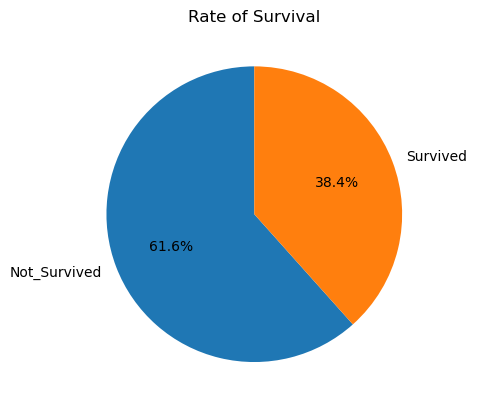

In [26]:
# Visualizing the survival rate using a pie chart
save_path = Path(r"C:\Users\ME\Desktop\AnalystLab\week1_2\Assets/images\survival_rate.png")
save_path.parent.mkdir(parents=True, exist_ok=True)

plt.pie(survival_df['Count'], labels=survival_df['Status'], autopct='%1.1f%%', startangle=90)
plt.title('Rate of Survival')
plt.savefig(save_path)
plt.show()

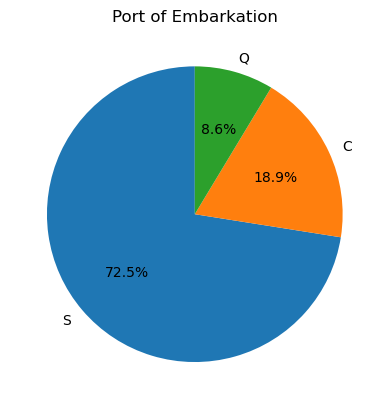

In [27]:
# Visualizing the Embarked port distribution
save_path = Path(r"C:\Users\ME\Desktop\AnalystLab\week1_2\Assets/images\Embarked.png")
save_path.parent.mkdir(parents=True, exist_ok=True)

plt.pie(titanic_df['Embarked'].value_counts(), 
        labels=titanic_df['Embarked'].value_counts().index, 
        autopct='%1.1f%%', 
        startangle=90)
plt.title('Port of Embarkation')
plt.savefig(save_path)
plt.show()
# most passengers boarded from Southampton (S), followed by Cherbourg (C) while only few from Queenstown (Q)

C:\Users\ME\AppData\Local\Temp\ipykernel_16208\2062462175.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic_df, x='Sex', palette=["#1367C1", "#E0AA73"])


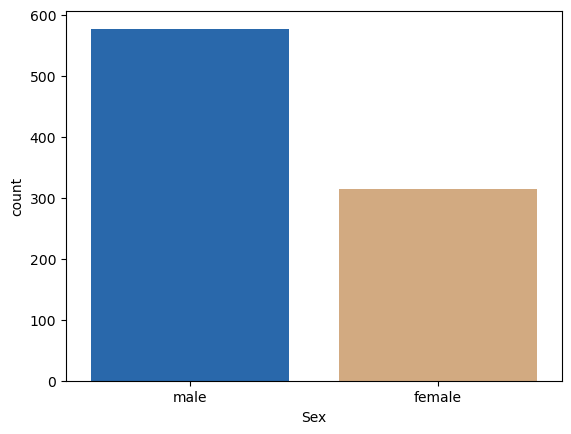

In [28]:
sns.countplot(data=titanic_df, x='Sex', palette=["#1367C1", "#E0AA73"])
plt.show()

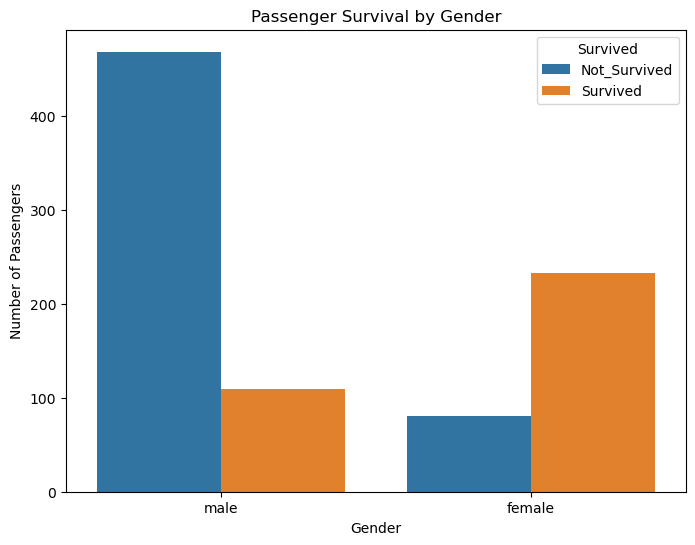

In [29]:
# titanic survival by Gender
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic_df, x='Sex', hue='Survived')
plt.title('Passenger Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.savefig(r"C:\Users\ME\Desktop\AnalystLab\week1_2\Assets/images\titanic_survival_by_gender.png")
plt.legend(title='Survived', labels=['Not_Survived', 'Survived'])
plt.show()

it indicate that there are more survivors in the female than men which might be as result of of women and children first policy during evacuation

In [30]:
print(f"Skewness of Age column: {titanic_df['Age'].skew()}")

Skewness of Age column: 0.5102446555756495


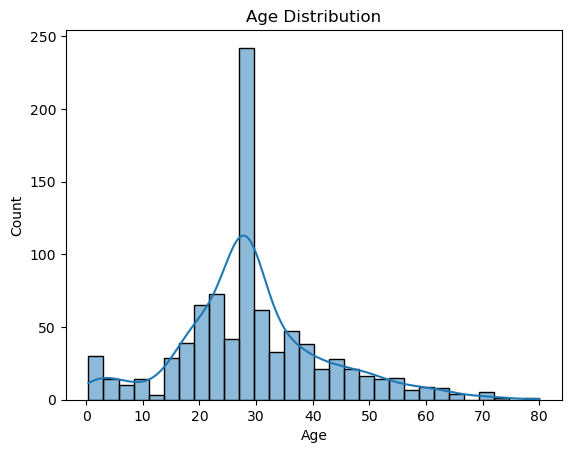

In [31]:

# Age distribution of the passengers onboard the Titanic
sns.histplot(titanic_df['Age'], kde=True)
plt.title('Age Distribution')
plt.show()
# most passengers are between the ages of 20 and 40, 
# wih relatively few children and few old

In [32]:
# Displaying the skewness of the Fare column
print(f" Fare Skewness: {titanic_df['Fare'].skew()}")
# the fare dist. is right-skewed, indicating that there are a few passengers 
# who paid significantly higher fares than the majority.

 Fare Skewness: 4.788357022826381


In [33]:
# checking how the "Age" is distributed normally or not 
titanic_df['Age'].value_counts().head(10)

Age
28.0    202
24.0     30
22.0     27
18.0     26
30.0     25
19.0     25
21.0     24
25.0     23
36.0     22
29.0     20
Name: count, dtype: int64

the spikes at age 28 - 30 reflects the median imputation of the Age missing values. the distribution clustering around the young to middle age makes sense as for a passenger ship carrying mostly working age-class and moderate presence of chldren and infants (families traveling)

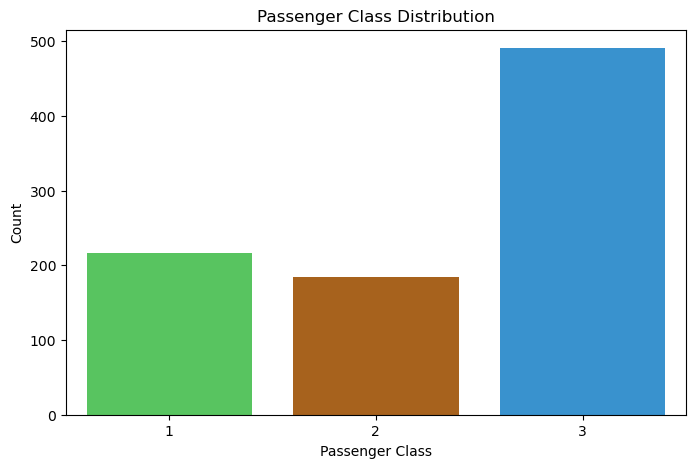

In [43]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=titanic_df,
    x='Pclass',
    hue='Pclass',
    palette=["#46D650", "#BE6206", "#2097E7"],
    legend=False
)
ax.set_title('Passenger Class Distribution')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Count')
plt.show()

In [34]:
pd.crosstab(titanic_df['Pclass'], titanic_df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


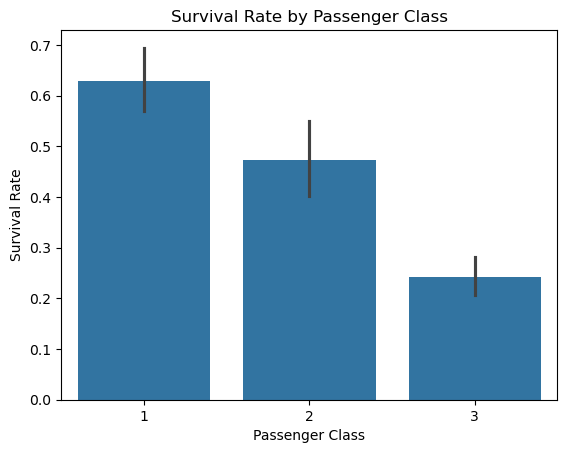

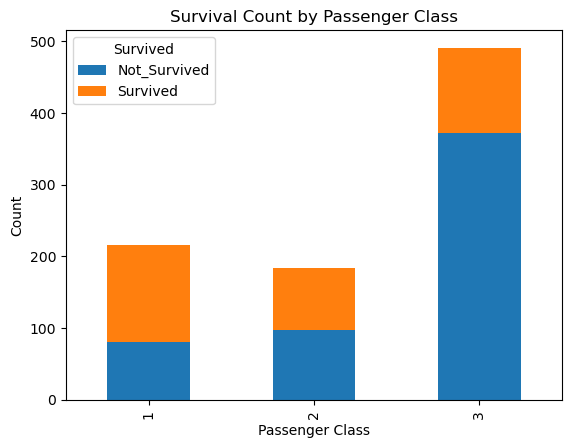

In [35]:
# Visualizing the survival rate by passenger class
sns.barplot(data=titanic_df, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

# showing the survival count by passenger class using a stacked bar chart
titanic_df.groupby('Pclass')['Survived'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['Not_Survived', 'Survived'])
plt.show()

the 1st class survival rate stands at 63%, 2nd class at 47% and 3rd class at 24% relatively 2x less likely to survive than the 1st class passeengers 

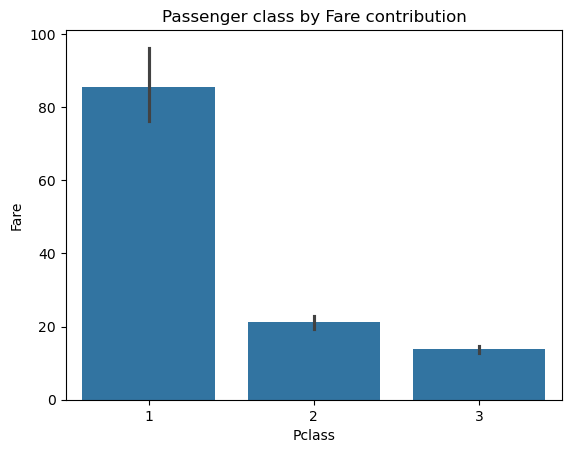

In [45]:
sns.barplot(data=titanic_df, x='Pclass', y='Fare')
plt.title('Passenger class by Fare contribution')
plt.show()
# 1st class passengers paid higher fare than those in 2nd or 3rd class
# Hence there is a relationship between Pclass and Fare

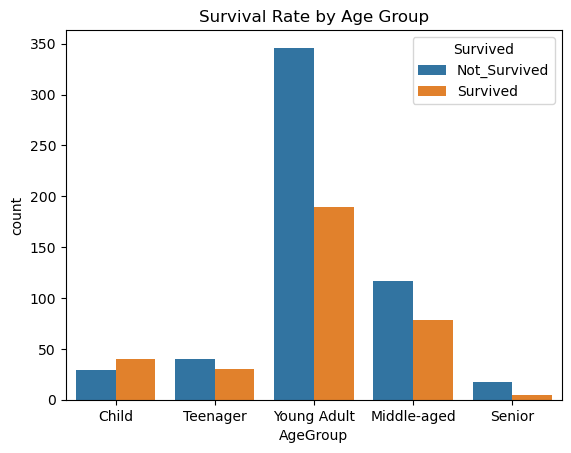

In [36]:
sns.countplot(data=titanic_df, x='AgeGroup', hue='Survived')
plt.title('Survival Rate by Age Group')
plt.legend(title='Survived', labels=['Not_Survived', 'Survived'])
plt.savefig(r"C:\Users\ME\Desktop\AnalystLab\week1_2\Assets\images\AgeGroup_survival_rate.png")
plt.show()

children is the sole group where survival is higher than death meaning survived outcome flips in their favor

In [52]:
numeric_columns = titanic_df.select_dtypes(include=[np.number]).columns.drop('PassengerId', errors='ignore')
correlation_matrix = titanic_df[numeric_columns].corr()
correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.250635
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.561243
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.099561
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.155423
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.212103
Fare,0.250635,-0.561243,0.099561,0.155423,0.212103,1.000000


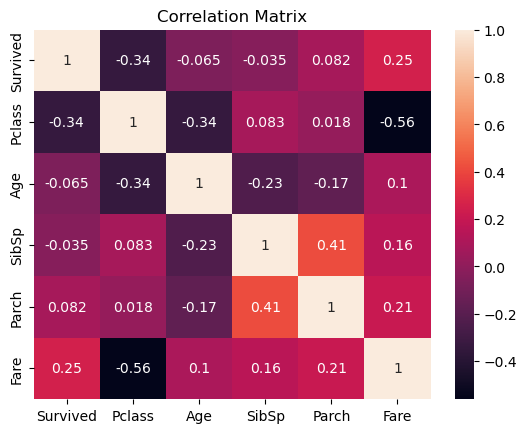

In [55]:
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix')
plt.savefig(r"C:\Users\ME\Desktop\AnalystLab\week1_2\Assets/images\correlation_matrix.png")
plt.show()

Exploratory Data Analysis (EDA) is a vital step in any data-driven project. In this analysis of the Titanic dataset, I uncovered several interesting patterns:

Gender: there are more male in the ship than women where Women were more likely to survive than men.

Class: First-class passengers had a much higher survival rate (2x) compared to third-class passengers.

Age: Passengers below the age of 40 are more likely to survive.

Fare: Those who paid higher fares (first-class passengers) had a better chance of survival.
EDA not only helps us understand the dataset but also guides future machine learning models by revealing important features that influence outcomes. This analysis can be further extended by building predictive models to estimate the survival likelihood of passengers based on their attributes.